# Multivariate Time-Series Anomaly Detection

## Project Overview

The goal of this project is to build an anomaly detection system that can identify abnormal patterns in multivariate telemetry/sensor time-series data.

Anomaly detection is important in real-world systems because abnormal behavior can indicate equipment failure, system instability, cyber-physical attacks, data quality issues, or early warning signs before a major incident occurs.

In this project, I will start by understanding and preparing the dataset, then build baseline anomaly detection models before moving to more advanced sequence-based models.

## Problem Statement

Given historical telemetry readings from a system, the objective is dataGiven historical telemetry readings from a system, the objective is to detect abnormal behavior in future readings.
- It is time-series based
- It contains labeled anomalies for evaluation
- It supports both simple baseline methods and more advanced sequence-based models
- It is relevant to practical monitoring use cases such as equipment monitoring, system health monitoring, and preventive maintenance

## Project Workflow

The project will follow these main stages:

1. Data collection
2. Data understanding
3. Exploratory data analysis
4. Data preprocessing
5. Feature engineering
6. Baseline anomaly detection models
7. Advanced anomaly detection models
8. Model evaluation
9. Error analysis and conclusions

## Evaluation Metrics

Since anomaly detection datasets are usually imbalanced, accuracy will not be the main metric.

The main evaluation metrics will include:

- Precision
- Recall
- F1-score
- Precision-Recall AUC
- False alarm rate

## Current Notebook Objective

This notebook focuses on the first stage of the project: data understanding.

The main questions to answer in this notebook are:

- What files are available in the dataset?
- What is the shape of the training data, test data, and labels?
- How many telemetry channels/features exist?
- How many anomaly points exist?
- What percentage of the test data is anomalous?
- Can we visualize sample telemetry channels and highlight anomaly regions?

The model should produce either:

- An anomaly score, where higher values indicate more abnormal behavior
- A binary prediction:
  - `0` = normal
  - `1` = anomaly

## Dataset

The planned dataset for this project is the NASA SMAP/MSL anomaly detection dataset.

This dataset contains telemetry readings from spacecraft/rover systems and includes labeled anomaly intervals, making it suitable for evaluating anomaly detection methods.

## Dataset Sources: SMAP and MSL

The dataset contains telemetry data from two NASA systems:

- **SMAP** stands for **Soil Moisture Active Passive**. It is a NASA Earth satellite mission designed to measure Earth’s soil moisture and freeze/thaw state.
- **MSL** stands for **Mars Science Laboratory**. It is NASA’s Mars rover mission associated with the Curiosity rover.

In this project, SMAP and MSL are used only as sources of telemetry time-series data. The goal is not to study soil moisture or Mars science directly, but to detect abnormal patterns in the telemetry signals produced by these systems.
``

## Why This Dataset?

This dataset is suitable for this project because:



## Dataset Structure

After downloading the NASA SMAP/MSL anomaly detection dataset, the raw data folder contains:

- `labeled_anomalies.xlsx`: metadata file containing the labeled anomaly intervals for different telemetry channels.
- `train/`: training telemetry data.
- `test/`: test telemetry data.
- Additional folders such as `models/`, `smoothed_errors/`, and `y_hat/`, which appear to contain outputs from an existing model pipeline.

For this project, I will focus on building my own end-to-end anomaly detection pipeline using the raw training data, raw test data, and labeled anomaly metadata.

The initial data preparation goal is to:

1. Inspect the available train and test files.
2. Understand the structure of the labeled anomalies file.
3. Select one telemetry channel with labeled anomalies.
4. Load its train and test data.
5. Convert anomaly intervals into binary labels.
6. Visualize the signal and its anomaly regions.

### Visualization (One Channel Example)
A Channel is a specific telemetry feature (e.g., temperature, pressure, etc.) that is being monitored over time. Each channel has its own time-series data and corresponding anomaly labels.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_dir = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw\train"
test_dir = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw\test"

channel_id = "A-1"

train_path = os.path.join(train_dir,f"{channel_id}.npy")
test_path = os.path.join(test_dir,f"{channel_id}.npy")

train_data = np.load(train_path)
test_data = np.load(test_path)


print("Channel:", channel_id)
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print("Train dimensions:", train_data.ndim)
print("Test dimensions:", test_data.ndim)



Channel: A-1
Train shape: (2880, 25)
Test shape: (8640, 25)
Train dimensions: 2
Test dimensions: 2


## Understanding the Labeled Anomalies Metadata

The dataset includes a metadata table with the following columns:

- `chan_id`: the telemetry channel identifier, matching `.npy` files in the train and test folders.
- `spacecraft`: the source system, either SMAP or MSL.
- `anomaly_sequences`: the labeled anomalous time ranges in the test signal.
- `class`: the anomaly type, such as point or contextual.
- `num_values`: the number of time steps in the test signal.

Each row describes the anomaly labels for one telemetry channel. The anomaly sequences refer to index ranges in the corresponding test file.

For example, channel `A-1` has the anomaly sequence `[[4690, 4774]]`, meaning that time steps from 4690 to 4774 in `test/A-1.npy` are labeled as anomalous.

For the first detailed analysis, I will start with channel `A-1` because it has a simple single anomaly interval and is suitable for validating the label creation and visualization pipeline.

## Anomaly Types: Point and Contextual

The dataset classifies anomalies into two main types:

- **Point anomaly**: a telemetry value or short range of values that is clearly abnormal on its own. These anomalies are often easier to detect using simple thresholds, alarms, or distance-based methods.

- **Contextual anomaly**: a value or sequence that may not look abnormal by itself, but becomes abnormal because of its surrounding time context or pattern. These anomalies usually require sequence-aware methods because the model needs to understand how the signal behaves over time.

For example, a sudden extreme spike can be considered a point anomaly, while a value that looks normal but appears at the wrong time or breaks the expected signal pattern can be considered a contextual anomaly.

## Intuition Behind the 25 Features

Although the file is named after a telemetry channel such as `A-1`, the loaded NumPy array for this channel has shape `(8640, 25)`. This means that the test data contains 8640 time steps, and each time step is represented by 25 feature values.

The exact physical meaning of each feature is not provided in the dataset. Therefore, I will treat these 25 columns as anonymized telemetry-related features that describe the system state at each time step.

A useful way to think about this is:

- `A-1` identifies the telemetry sequence being analyzed.
- The 25 features are the values available at each time step for that sequence.
- The anomaly label applies to the time step, not to one specific feature column.

For example, the anomaly interval `[4690, 4774]` means that rows 4690 through 4774 are labeled as anomalous. Each of these rows contains 25 feature values:

`test_signal[4690, :]` represents all 25 feature values at time step 4690.

During visualization, some features may show the anomaly clearly, while others may not. For channel `A-1`, Feature `0` shows a clear abnormal drop at time step `4750`, which lies inside the labeled anomaly interval. Other features appear to behave like binary or sparse indicator variables, and some are nearly constant.

This means that the anomaly may be visible in only one feature, multiple features, or in the relationship between features over time. In multivariate anomaly detection, the model can use all available features together to learn normal system behavior and detect abnormal time periods.

A practical analogy is a machine monitored over time. One time step may include several readings, such as temperature, pressure, motor state, command status, and vibration. Even if the anomaly is only obvious in one reading, the full set of readings helps describe the machine's state at that moment.

In this dataset, the feature names are anonymized, so I do not assume what each feature physically represents. Instead, I analyze their statistical behavior and visual patterns.

Channel: A-1
Train shape: (2880, 25)
Test shape: (8640, 25)
Number of test points: 8640
Number of anomalous points: 84
Anomaly percentage: 0.97 %


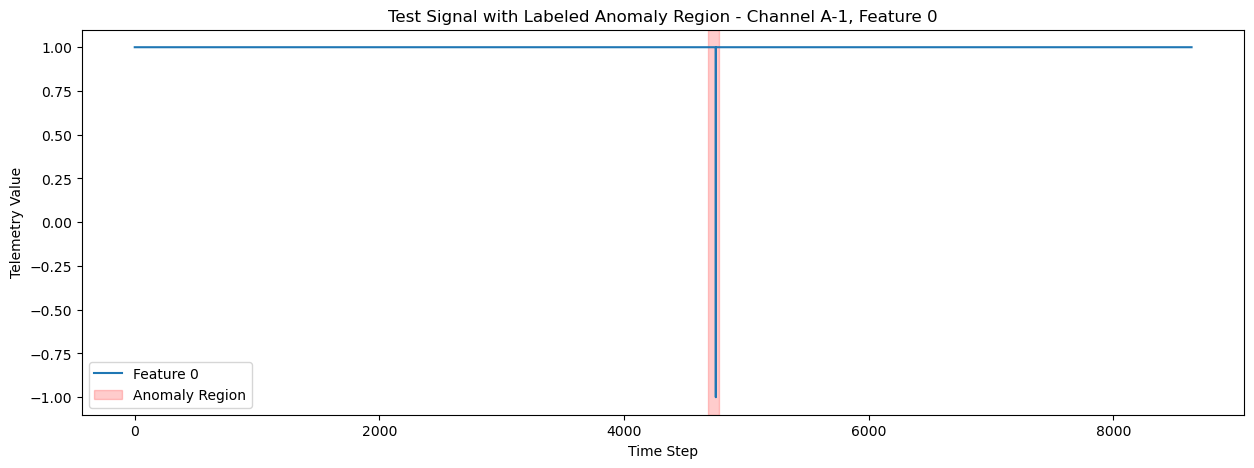

In [10]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw"

train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")

channel_id = "A-1"

train_path = os.path.join(train_dir, f"{channel_id}.npy")
test_path = os.path.join(test_dir, f"{channel_id}.npy")

train_signal = np.load(train_path).squeeze()
test_signal = np.load(test_path).squeeze()


print("Channel:", channel_id)
print("Train shape:", train_signal.shape)
print("Test shape:", test_signal.shape)

# Creating anomaly label array manually first channel A-1 based on the provided anomaly intervals
A_1_anomaly = [[4690, 4774]]

test_labels = np.zeros(len(test_signal), dtype=int)
for start, end in A_1_anomaly:
    test_labels[start:end] = 1


print("Number of test points:", len(test_signal))
print("Number of anomalous points:", test_labels.sum())
print("Anomaly percentage:", round(test_labels.mean() * 100, 2), "%")

# Visualize the signal and anomalies
feature_idx = 0

test_feature = test_signal[:, feature_idx]

plt.figure(figsize=(15, 5))

plt.plot(test_feature, label=f"Feature {feature_idx}")

for i, (start, end) in enumerate(A_1_anomaly):
    label = "Anomaly Region" if i == 0 else None
    plt.axvspan(start, end, color="red", alpha=0.2, label=label)

plt.title(f"Test Signal with Labeled Anomaly Region - Channel {channel_id}, Feature {feature_idx}")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()
plt.show()

### Zooming Into The Anomaly Region 
To better understand the anomaly, I will zoom into the specific time range of the anomaly interval and visualize the signal in that region. This will help me see how the signal behaves around the anomaly and whether it is a point or contextual anomaly.

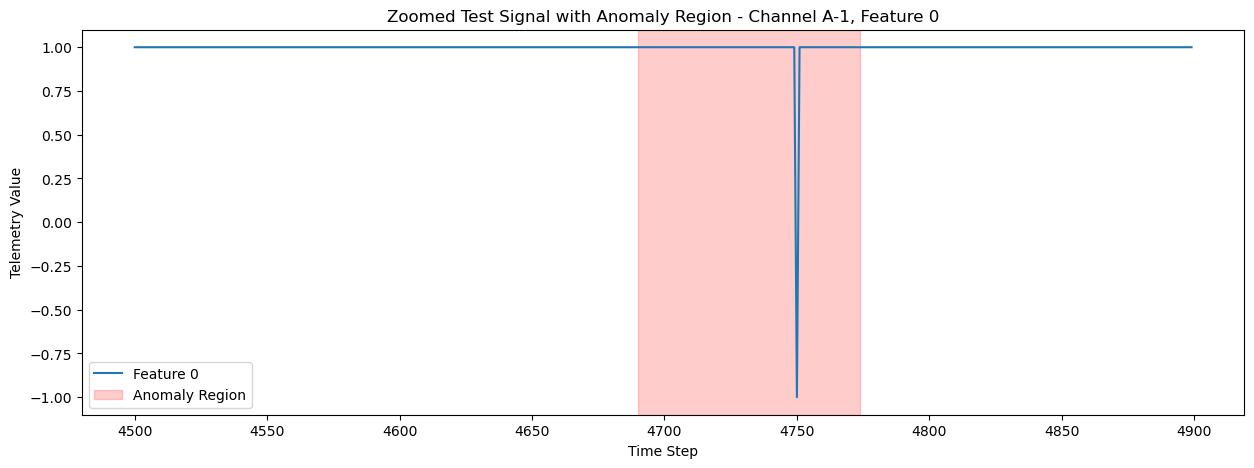

In [12]:
feature_idx = 0

start_zoom = 4500
end_zoom = 4900

test_feature = test_signal[:, feature_idx]

plt.figure(figsize=(15, 5))

plt.plot(
    range(start_zoom, end_zoom),
    test_feature[start_zoom:end_zoom],
    label=f"Feature {feature_idx}"
)

for i, (start, end) in enumerate(A_1_anomaly):
    label = "Anomaly Region" if i == 0 else None
    plt.axvspan(start, end, color="red", alpha=0.2, label=label)

plt.title(f"Zoomed Test Signal with Anomaly Region - Channel {channel_id}, Feature {feature_idx}")
plt.xlabel("Time Step")
plt.ylabel("Telemetry Value")
plt.legend()
plt.show()

The zoomed plot for channel `A-1`, feature `0`, shows that the feature is mostly constant at value `1.0`. Within the labeled anomaly interval `[4690, 4774]`, there is a sharp drop to approximately `-1.0` around time step `4750`.

This confirms that the labeled anomaly region aligns with a visible abnormal change in at least one feature. However, the anomaly label applies to the full time interval and to the full multivariate row, not only to feature `0`.

### Now I will find exactly where Feature 0 changes  

In [13]:
feature_idx = 0

test_feature = test_signal[:, feature_idx]

anomaly_start, anomaly_end = A_1_anomaly[0]

anomaly_feature_values = test_feature[anomaly_start:anomaly_end + 1]

print("Anomaly interval:", anomaly_start, anomaly_end)
print("Unique values inside anomaly interval:", np.unique(anomaly_feature_values))
print("Minimum value inside anomaly interval:", anomaly_feature_values.min())
print("Maximum value inside anomaly interval:", anomaly_feature_values.max())

drop_indices = np.where(test_feature == -1)[0]

print("Indices where Feature 0 equals -1:")
print(drop_indices)

Anomaly interval: 4690 4774
Unique values inside anomaly interval: [-1.  1.]
Minimum value inside anomaly interval: -1.0
Maximum value inside anomaly interval: 1.0
Indices where Feature 0 equals -1:
[4750]


### Now I will plot several features together to see if the anomaly is visible in multiple features or just one.

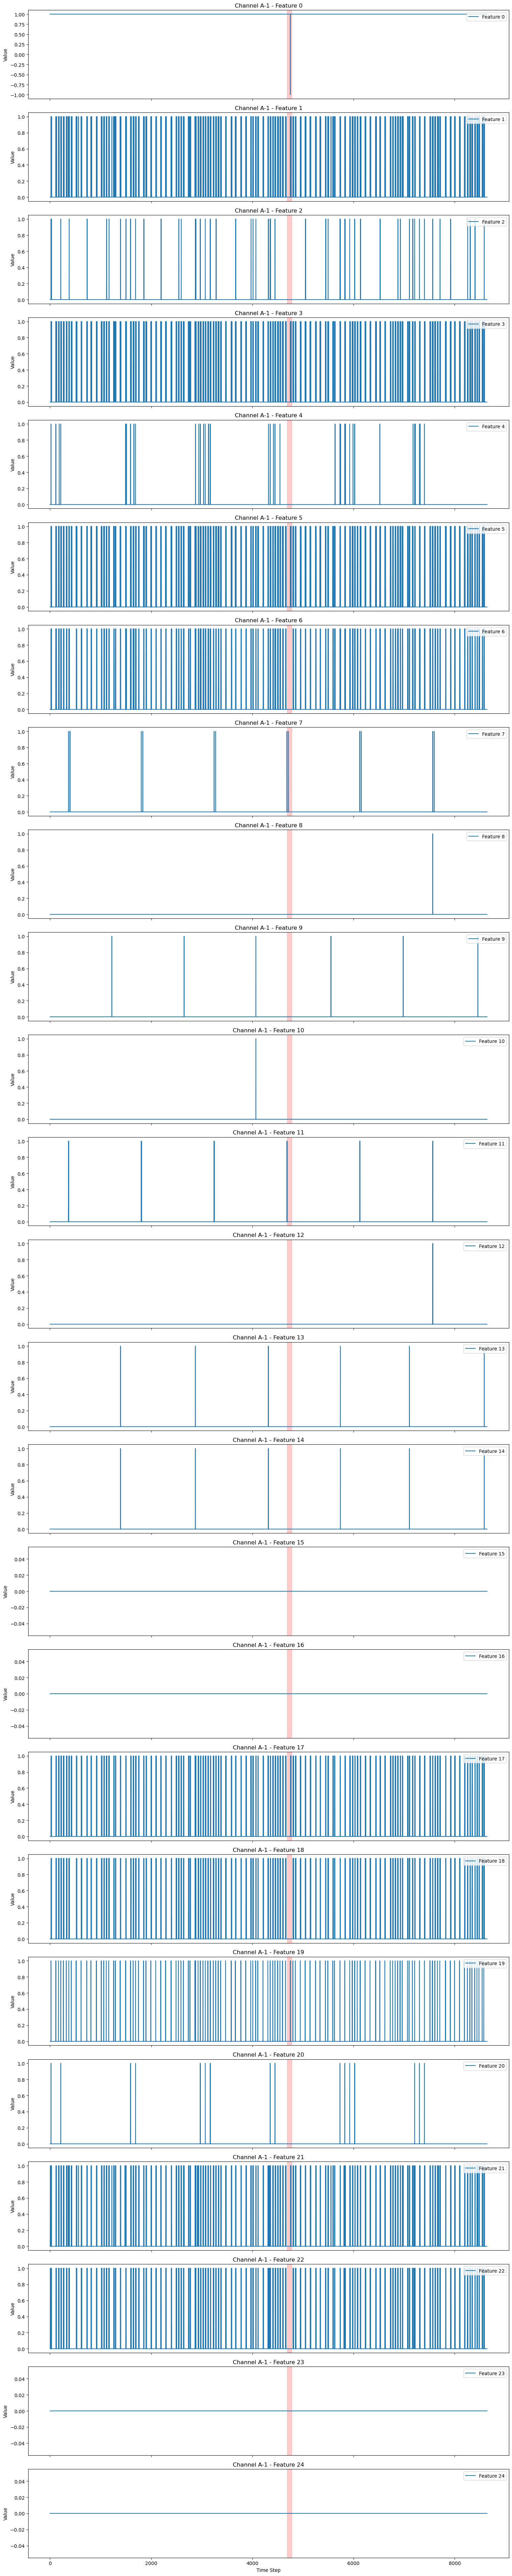

In [15]:
num_features_to_plot = 25

fig, axes = plt.subplots(num_features_to_plot, 1, figsize=(15, 3 * num_features_to_plot), sharex=True)

for feature_idx in range(num_features_to_plot):
    feature_values = test_signal[:, feature_idx]
    
    axes[feature_idx].plot(feature_values, label=f"Feature {feature_idx}")
    
    for start, end in A_1_anomaly:
        axes[feature_idx].axvspan(start, end, color="red", alpha=0.2)
    
    axes[feature_idx].set_title(f"Channel {channel_id} - Feature {feature_idx}")
    axes[feature_idx].set_ylabel("Value")
    axes[feature_idx].legend(loc="upper right")

axes[-1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()

For channel `A-1`, the labeled anomaly interval is `[4690, 4774]`.

Feature `0` is mostly constant at value `1.0`, but it drops to `-1.0` at exactly time step `4750`, which lies inside the labeled anomaly interval. This suggests that the anomaly is clearly visible in Feature `0`.

After plotting all 25 features for channel `A-1`, Feature `0` shows the clearest visible anomaly. It is mostly constant at `1.0`, but drops to `-1.0` at time step `4750`, which lies inside the labeled anomaly interval `[4690, 4774]`.

Many other features appear to be binary or sparse indicator-like variables that switch between `0` and `1`. Some features are almost constant and may provide limited information for anomaly detection.

This confirms that the anomaly label is aligned with the time dimension, not with a specific feature. The labeled anomaly interval marks anomalous time steps, while individual features may show the anomaly with different levels of visibility.

In [17]:
feature_summary = pd.DataFrame({
    "feature_index": range(test_signal.shape[1]),
    "mean": test_signal.mean(axis=0),
    "std": test_signal.std(axis=0),
    "min": test_signal.min(axis=0),
    "max": test_signal.max(axis=0),
    "unique_values": [len(np.unique(test_signal[:, i])) for i in range(test_signal.shape[1])]
})

feature_summary
feature_summary.sort_values("std", ascending=False)



,feature_index,mean,std,min,max,unique_values
15,15,0.0,0.0,0.0,0.0,1
16,16,0.0,0.0,0.0,0.0,1
23,23,0.0,0.0,0.0,0.0,1
24,24,0.0,0.0,0.0,0.0,1


Other plotted features appear to behave like binary or sparse indicator features, switching between `0` and `1`. The anomaly is not equally visible across all features, which is expected in multivariate anomaly detection. The label applies to the full time step, while individual features may show the anomaly with different levels of visibility.

In [18]:
constant_features = feature_summary[feature_summary["std"] == 0]

constant_features

,feature_index,mean,std,min,max,unique_values
15,15,0.0,0.0,0.0,0.0,1
16,16,0.0,0.0,0.0,0.0,1
23,23,0.0,0.0,0.0,0.0,1
24,24,0.0,0.0,0.0,0.0,1


In [19]:
binary_like_features = feature_summary[feature_summary["unique_values"] <= 2]

binary_like_features

,feature_index,mean,std,min,max,unique_values
0,0,0.999769,0.021515,-1.0,1.0,2
1,1,0.036806,0.188284,0.0,1.0,2
2,2,0.009375,0.096370,0.0,1.0,2
3,3,0.028241,0.165660,0.0,1.0,2
4,4,0.004167,0.064415,0.0,1.0,2
5,5,0.170139,0.375755,0.0,1.0,2
6,6,0.135185,0.341921,0.0,1.0,2
7,7,0.001389,0.037242,0.0,1.0,2
8,8,0.000116,0.010758,0.0,1.0,2
9,9,0.000694,0.026343,0.0,1.0,2


Create the final test labels array for A-1, where `1` indicates an anomaly and `0` indicates normal.

In [20]:
test_labels = np.zeros(test_signal.shape[0], dtype=int)

for start, end in A_1_anomaly:
    test_labels[start:end + 1] = 1

print("Test signal shape:", test_signal.shape)
print("Test labels shape:", test_labels.shape)
print("Number of anomalous time steps:", test_labels.sum())
print("Anomaly percentage:", round(test_labels.mean() * 100, 2), "%")

Test signal shape: (8640, 25)
Test labels shape: (8640,)
Number of anomalous time steps: 85
Anomaly percentage: 0.98 %


A-1 is a multivariate time-series sample with 8640 time steps and 25 features. The labeled anomaly interval is from 4690 to 4774. Feature 0 shows a clear abnormal drop at time step 4750, while other features are mostly binary, sparse, or constant. The label applies to the time steps, not to individual feature columns.

## Dataset-Level Understanding

After validating the structure using channel `A-1`, the next step is to summarize the full dataset across all available telemetry channels.

The goal of this section is to understand the dataset at a broader level before moving to data preparation and preprocessing.

This section will answer:

- How many labeled channels are available?
- How many channels belong to SMAP and MSL?
- How many anomalies are point anomalies versus contextual anomalies?
- How many anomaly intervals exist per channel?
- What are the train and test shapes for each channel?
- Do the metadata `num_values` match the actual test file lengths?
- Do all channels have the same number of features?

### Step 1: Load and Inspect Full Metadata

In [24]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DATA_DIR = r"C:\Users\user\OneDrive - TechnoVal\Desktop\Scripts\ML\anomaly-detection-project\data\raw"
train_dir = os.path.join(DATA_DIR, "train")
test_dir = os.path.join(DATA_DIR, "test")


labels_path = os.path.join(DATA_DIR, "labeled_anomalies.csv")

labels_df = pd.read_csv(labels_path)

labels_df.head()



,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [25]:
print("Metadata shape:", labels_df.shape)
print("\nColumns:")
print(labels_df.columns)

print("\nSpacecraft distribution:")
print(labels_df["spacecraft"].value_counts())

print("\nNumber of unique channels:")
print(labels_df["chan_id"].nunique())

Metadata shape: (82, 5)

Columns:
Index(['chan_id', 'spacecraft', 'anomaly_sequences', 'class', 'num_values'], dtype='object')

Spacecraft distribution:
spacecraft
SMAP    55
MSL     27
Name: count, dtype: int64

Number of unique channels:
81


### Step 2: Parse Anomaly Sequences and Classes

In [29]:
import ast
import pandas as pd

def parse_anomaly_sequences(value):
    if isinstance(value, str):
        return ast.literal_eval(value)
    return value

def parse_class_labels(value):
    if isinstance(value, list):
        return value
    
    if pd.isna(value):
        return []
    
    if isinstance(value, str):
        # Remove square brackets
        value = value.strip()
        value = value.replace("[", "").replace("]", "")
        
        # Split by comma and clean spaces
        labels = [item.strip() for item in value.split(",")]
        
        # Remove empty strings if any
        labels = [label for label in labels if label]
        
        return labels
    
    return value

labels_df["anomaly_sequences_parsed"] = labels_df["anomaly_sequences"].apply(parse_anomaly_sequences)
labels_df["class_parsed"] = labels_df["class"].apply(parse_class_labels)

labels_df[[
    "chan_id",
    "spacecraft",
    "anomaly_sequences",
    "anomaly_sequences_parsed",
    "class",
    "class_parsed",
    "num_values"
]].head()

,chan_id,spacecraft,anomaly_sequences,anomaly_sequences_parsed,class,class_parsed,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]","[[5300, 5747]]",[point],[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[[5000, 5030], [5610, 6086]]","[contextual, contextual]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]","[[5598, 6995]]",[point],[point],8532
4,E-3,SMAP,"[[5094, 8306]]","[[5094, 8306]]",[point],[point],8307


In [ ]:
sample_row = labels_df.iloc[0]

print("Original anomaly_sequences:")
print(sample_row["anomaly_sequences"])
print("Type:", type(sample_row["anomaly_sequences"]))

print("\nParsed anomaly_sequences:")
print(sample_row["anomaly_sequences_parsed"])
print("Type:", type(sample_row["anomaly_sequences_parsed"]))

print("\nOriginal class:")
print(sample_row["class"])
print("Type:", type(sample_row["class"]))

print("\nParsed class:")
print(sample_row["class_parsed"])
print("Type:", type(sample_row["class_parsed"]))

Original anomaly_sequences:
[[2149, 2349], [4536, 4844], [3539, 3779]]
Type: <class 'str'>

Parsed anomaly_sequences:
[[2149, 2349], [4536, 4844], [3539, 3779]]
Type: <class 'list'>

Original class:
[contextual, contextual, contextual]
Type: <class 'str'>

Parsed class:
['contextual', 'contextual', 'contextual']
Type: <class 'list'>


### Step 3: Validate Parsed Metadata

In [33]:
labels_df["num_anomaly_intervals"] = labels_df["anomaly_sequences_parsed"].apply(len)
labels_df["num_class_labels"] = labels_df["class_parsed"].apply(len)

labels_df[
    [
        "chan_id",
        "spacecraft",
        "anomaly_sequences_parsed",
        "class_parsed",
        "num_anomaly_intervals",
        "num_class_labels",
        "num_values"
    ]
].head(10)

,chan_id,spacecraft,anomaly_sequences_parsed,class_parsed,num_anomaly_intervals,num_class_labels,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",3,3,8505
1,S-1,SMAP,"[[5300, 5747]]",[point],1,1,7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",2,2,8516
3,E-2,SMAP,"[[5598, 6995]]",[point],1,1,8532
4,E-3,SMAP,"[[5094, 8306]]",[point],1,1,8307
5,E-4,SMAP,"[[5450, 8261]]",[point],1,1,8354
6,E-5,SMAP,"[[5600, 5920]]",[point],1,1,8294
7,E-6,SMAP,"[[5610, 5675]]",[point],1,1,8300
8,E-7,SMAP,"[[5394, 5674]]",[point],1,1,8310
9,E-8,SMAP,"[[5400, 6022]]",[point],1,1,8532


In [34]:
mismatches = labels_df[
    labels_df["num_anomaly_intervals"] != labels_df["num_class_labels"]
]

print("Number of mismatched rows:", len(mismatches))

mismatches

Number of mismatched rows: 0


,chan_id,spacecraft,anomaly_sequences,class,num_values,anomaly_sequences_parsed,class_parsed,num_anomaly_intervals,num_class_labels


### Step 4: Dataset-Level Metadata Summary

After validating the parsed metadata, I summarize the dataset at a high level.

This step answers:

- How many metadata rows are available?
- How many unique telemetry channels exist?
- How many channels belong to SMAP and MSL?
- How many anomaly intervals exist per channel?
- Which channels contain multiple anomaly intervals?

In [35]:
print("Total metadata rows:", len(labels_df))
print("Unique channels:", labels_df["chan_id"].nunique())

print("\nSpacecraft distribution:")
print(labels_df["spacecraft"].value_counts())

print("\nAnomaly intervals per channel summary:")
print(labels_df["num_anomaly_intervals"].describe())

Total metadata rows: 82
Unique channels: 81

Spacecraft distribution:
spacecraft
SMAP    55
MSL     27
Name: count, dtype: int64

Anomaly intervals per channel summary:
count    82.000000
mean      1.280488
std       0.572506
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: num_anomaly_intervals, dtype: float64


The metadata contains 82 rows and 81 unique channels, meaning one channel appears more than once. The dataset includes 55 SMAP entries and 27 MSL entries.

The `num_anomaly_intervals` summary shows that most channel entries contain only one labeled anomaly interval. The average number of anomaly intervals per metadata row is approximately 1.28, while the maximum is 3. This means the dataset is mostly composed of single-anomaly channels, with a smaller number of channels containing multiple anomaly intervals.

In [36]:
labels_df["chan_id"].value_counts()[labels_df["chan_id"].value_counts() > 1]

chan_id
P-2    2
Name: count, dtype: int64

In [38]:
labels_df[labels_df["chan_id"].duplicated(keep=False)]

,chan_id,spacecraft,anomaly_sequences,class,num_values,anomaly_sequences_parsed,class_parsed,num_anomaly_intervals,num_class_labels
17,P-2,SMAP,"[[5350, 6575]]",[point],8209,"[[5350, 6575]]",[point],1,1
51,P-2,SMAP,"[[5300, 6420]]",[point],8209,"[[5300, 6420]]",[point],1,1


### Step 5: Anomaly Type Distribution

After summarizing the metadata rows and anomaly intervals, I now analyze the distribution of anomaly types across the full dataset.

Some channels contain more than one anomaly interval, and each interval has its own anomaly type. Therefore, I expand the anomaly class labels so that each anomaly interval is counted separately.

This step helps answer:

- How many point anomalies exist?
- How many contextual anomalies exist?
- How are anomaly types distributed between SMAP and MSL?

In [39]:
anomaly_type_rows = []

for _, row in labels_df.iterrows():
    channel_id = row["chan_id"]
    spacecraft = row["spacecraft"]
    classes = row["class_parsed"]
    
    for anomaly_class in classes:
        anomaly_type_rows.append({
            "chan_id": channel_id,
            "spacecraft": spacecraft,
            "anomaly_type": anomaly_class
        })

anomaly_types_df = pd.DataFrame(anomaly_type_rows)

anomaly_types_df.head()

,chan_id,spacecraft,anomaly_type
0,P-1,SMAP,contextual
1,P-1,SMAP,contextual
2,P-1,SMAP,contextual
3,S-1,SMAP,point
4,E-1,SMAP,contextual


In [40]:
print("Anomaly type distribution:")
print(anomaly_types_df["anomaly_type"].value_counts())

Anomaly type distribution:
anomaly_type
point         62
contextual    43
Name: count, dtype: int64


In [41]:
print("Anomaly type distribution by spacecraft:")
print(pd.crosstab(anomaly_types_df["spacecraft"], anomaly_types_df["anomaly_type"]))


Anomaly type distribution by spacecraft:
anomaly_type  contextual  point
spacecraft                     
MSL                   17     19
SMAP                  26     43


The anomaly type distribution shows the number of labeled anomaly intervals categorized as point or contextual anomalies.

This is different from counting metadata rows because some channels contain multiple anomaly intervals. By expanding the class labels, each anomaly interval is counted separately.

This summary helps understand whether the dataset is dominated by simple point anomalies or more complex contextual anomalies.

The anomaly type distribution shows that the dataset contains both point and contextual anomalies.

Across the full dataset, there are 62 point anomaly intervals and 43 contextual anomaly intervals, for a total of 105 labeled anomaly intervals.

SMAP contains 69 anomaly intervals in total, with 43 point anomalies and 26 contextual anomalies. MSL contains 36 anomaly intervals in total, with 19 point anomalies and 17 contextual anomalies.

This means the dataset is not limited to one type of anomaly. It includes both simpler point anomalies, which may be detectable using thresholds or distance-based methods, and more complex contextual anomalies, which may require sequence-aware models.

### Step 6: Inspect Train and Test Shapes Across All Channels

After summarizing the metadata and anomaly type distribution, I inspect the actual `.npy` files for all labeled channels.

This step checks whether every labeled channel has a corresponding train and test file, what the shape of each array is, how many features each channel contains, and whether the metadata `num_values` matches the actual number of time steps in the test file.

This validation is important before preprocessing because it confirms whether the metadata and raw data are aligned.

In [43]:
shape_rows = []

for _, row in labels_df.iterrows():
    channel_id = row["chan_id"]
    spacecraft = row["spacecraft"]
    metadata_num_values = row["num_values"]
    
    train_path = os.path.join(train_dir, f"{channel_id}.npy")
    test_path = os.path.join(test_dir, f"{channel_id}.npy")
    
    train_exists = os.path.exists(train_path)
    test_exists = os.path.exists(test_path)
    
    train_shape = None
    test_shape = None
    train_length = None
    test_length = None
    num_features = None
    metadata_matches_test_length = None
    
    if train_exists:
        train_data = np.load(train_path)
        train_shape = train_data.shape
        train_length = train_data.shape[0]
    
    if test_exists:
        test_data = np.load(test_path)
        test_shape = test_data.shape
        test_length = test_data.shape[0]
        
        if test_data.ndim == 1:
            num_features = 1
        else:
            num_features = test_data.shape[1]
        
        metadata_matches_test_length = test_length == metadata_num_values
    
    shape_rows.append({
        "chan_id": channel_id,
        "spacecraft": spacecraft,
        "train_exists": train_exists,
        "test_exists": test_exists,
        "train_shape": train_shape,
        "test_shape": test_shape,
        "train_length": train_length,
        "test_length": test_length,
        "metadata_num_values": metadata_num_values,
        "metadata_matches_test_length": metadata_matches_test_length,
        "num_features": num_features,
        "num_anomaly_intervals": row["num_anomaly_intervals"],
        "class_parsed": row["class_parsed"]
    })

shapes_df = pd.DataFrame(shape_rows)

shapes_df.head()

,chan_id,spacecraft,train_exists,test_exists,train_shape,test_shape,train_length,test_length,metadata_num_values,metadata_matches_test_length,num_features,num_anomaly_intervals,class_parsed
0,P-1,SMAP,True,True,"(2872, 25)","(8505, 25)",2872,8505,8505,True,25,3,"[contextual, contextual, contextual]"
1,S-1,SMAP,True,True,"(2818, 25)","(7331, 25)",2818,7331,7331,True,25,1,[point]
2,E-1,SMAP,True,True,"(2880, 25)","(8516, 25)",2880,8516,8516,True,25,2,"[contextual, contextual]"
3,E-2,SMAP,True,True,"(2880, 25)","(8532, 25)",2880,8532,8532,True,25,1,[point]
4,E-3,SMAP,True,True,"(2880, 25)","(8307, 25)",2880,8307,8307,True,25,1,[point]


In [44]:
print("Number of metadata rows inspected:", len(shapes_df))
print("Number of unique channels inspected:", shapes_df["chan_id"].nunique())

print("\nMissing train files:")
display(shapes_df[shapes_df["train_exists"] == False])

print("\nMissing test files:")
display(shapes_df[shapes_df["test_exists"] == False])

print("\nMetadata/test length match:")
print(shapes_df["metadata_matches_test_length"].value_counts(dropna=False))

print("\nNumber of features distribution:")
print(shapes_df["num_features"].value_counts(dropna=False))

print("\nTest length summary:")
print(shapes_df["test_length"].describe())

Number of metadata rows inspected: 82
Number of unique channels inspected: 81

Missing train files:


,chan_id,spacecraft,train_exists,test_exists,train_shape,test_shape,train_length,test_length,metadata_num_values,metadata_matches_test_length,num_features,num_anomaly_intervals,class_parsed



Missing test files:


,chan_id,spacecraft,train_exists,test_exists,train_shape,test_shape,train_length,test_length,metadata_num_values,metadata_matches_test_length,num_features,num_anomaly_intervals,class_parsed



Metadata/test length match:
metadata_matches_test_length
True    82
Name: count, dtype: int64

Number of features distribution:
num_features
25    55
55    27
Name: count, dtype: int64

Test length summary:
count      82.000000
mean     6314.195122
std      2701.236724
min      1096.000000
25%      2997.500000
50%      7895.500000
75%      8472.000000
max      8640.000000
Name: test_length, dtype: float64


The train/test shape inspection confirms that all 82 metadata rows match the actual test file lengths, meaning the `num_values` metadata column is consistent with the raw `.npy` files.

The feature dimension differs by spacecraft source. The dataset contains 55 entries with 25 features and 27 entries with 55 features. This likely corresponds to SMAP channels having 25 features and MSL channels having 55 features.

The test sequence lengths vary significantly, ranging from 1096 to 8640 time steps, with an average length of approximately 6314 time steps. This means future preprocessing and modeling steps must handle variable sequence lengths.

For the first modeling version, it may be practical to start with SMAP channels only because they share the same feature dimension of 25.

#### Feature Dimensions by Spacecraft

The previous summary showed that some channels have 25 features while others have 55 features. To understand whether this difference is related to the source spacecraft, I compare the number of features against the `spacecraft` column.

In [47]:
pd.crosstab(shapes_df["spacecraft"], shapes_df["num_features"])

num_features,25,55
spacecraft,,
MSL,0,27
SMAP,55,0


The feature dimension is consistent within each spacecraft source. SMAP entries have 25 features, while MSL entries have 55 features.

This means the dataset contains two groups with different input dimensions. For modeling, SMAP and MSL may need to be handled separately, or a preprocessing strategy must be used to make the feature dimensions compatible.

For the first modeling version, it may be simpler to start with SMAP channels only because all SMAP entries share the same 25-feature structure.

### Summary

The train/test shape inspection confirms that all metadata rows match the actual test file lengths. This means the `num_values` column is consistent with the number of time steps in the corresponding test `.npy` files.

The dataset has two different feature dimensions. SMAP entries contain 25 features per time step, while MSL entries contain 55 features per time step. This difference is important for future modeling because SMAP and MSL cannot be directly combined into one model input without handling the feature dimension mismatch.

The test sequence lengths vary significantly, ranging from 1096 to 8640 time steps. This means future preprocessing and modeling steps must handle variable-length time series.

### Step 7: Quick EDA on Representative Channels

After validating the metadata and inspecting train/test shapes across all channels, I perform a quick EDA on a small set of representative channels.

The purpose of this step is not to analyze every channel manually, but to inspect examples that represent different cases in the dataset:

- A simple point anomaly channel
- A contextual anomaly channel
- A channel with multiple anomaly intervals
- An MSL channel with a different feature dimension

This helps confirm that anomaly behavior differs across channels and supports the need for a flexible preprocessing and modeling pipeline.

In [49]:
representative_channels = ["A-2", "P-1", "C-1"]

labels_df[
    labels_df["chan_id"].isin(representative_channels)
][
    [
        "chan_id",
        "spacecraft",
        "anomaly_sequences_parsed",
        "class_parsed",
        "num_values",
        "num_anomaly_intervals"
    ]
]

,chan_id,spacecraft,anomaly_sequences_parsed,class_parsed,num_values,num_anomaly_intervals
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505,3
22,A-2,SMAP,"[[4450, 4560]]",[contextual],7914,1
67,C-1,MSL,"[[550, 750], [2100, 2210]]","[point, contextual]",2264,2


In [50]:
def get_channel_metadata(labels_df, channel_id):
    channel_rows = labels_df[labels_df["chan_id"] == channel_id]
    
    if len(channel_rows) == 0:
        raise ValueError(f"Channel {channel_id} not found in metadata.")
    
    if len(channel_rows) > 1:
        print(f"Warning: Channel {channel_id} has multiple metadata rows. Using the first row.")
    
    return channel_rows.iloc[0]

In [51]:
def load_channel_data(channel_id, train_dir, test_dir):
    train_path = os.path.join(train_dir, f"{channel_id}.npy")
    test_path = os.path.join(test_dir, f"{channel_id}.npy")
    
    train_data = np.load(train_path)
    test_data = np.load(test_path)
    
    return train_data, test_data

In [52]:
def create_binary_labels(test_length, anomaly_sequences):
    labels = np.zeros(test_length, dtype=int)
    
    for start, end in anomaly_sequences:
        labels[start:end + 1] = 1
    
    return labels

In [53]:
def summarize_channel(channel_id, labels_df, train_dir, test_dir):
    metadata = get_channel_metadata(labels_df, channel_id)
    train_data, test_data = load_channel_data(channel_id, train_dir, test_dir)
    
    anomaly_sequences = metadata["anomaly_sequences_parsed"]
    anomaly_classes = metadata["class_parsed"]
    test_labels = create_binary_labels(test_data.shape[0], anomaly_sequences)
    
    summary = {
        "channel_id": channel_id,
        "spacecraft": metadata["spacecraft"],
        "train_shape": train_data.shape,
        "test_shape": test_data.shape,
        "num_features": test_data.shape[1] if test_data.ndim > 1 else 1,
        "num_anomaly_intervals": len(anomaly_sequences),
        "anomaly_sequences": anomaly_sequences,
        "anomaly_classes": anomaly_classes,
        "anomalous_time_steps": int(test_labels.sum()),
        "anomaly_percentage": round(test_labels.mean() * 100, 2)
    }
    
    return summary

In [54]:
for channel_id in representative_channels:
    summary = summarize_channel(channel_id, labels_df, train_dir, test_dir)
    print("\n" + "=" * 80)
    for key, value in summary.items():
        print(f"{key}: {value}")


channel_id: A-2
spacecraft: SMAP
train_shape: (2648, 25)
test_shape: (7914, 25)
num_features: 25
num_anomaly_intervals: 1
anomaly_sequences: [[4450, 4560]]
anomaly_classes: ['contextual']
anomalous_time_steps: 111
anomaly_percentage: 1.4

channel_id: P-1
spacecraft: SMAP
train_shape: (2872, 25)
test_shape: (8505, 25)
num_features: 25
num_anomaly_intervals: 3
anomaly_sequences: [[2149, 2349], [4536, 4844], [3539, 3779]]
anomaly_classes: ['contextual', 'contextual', 'contextual']
anomalous_time_steps: 751
anomaly_percentage: 8.83

channel_id: C-1
spacecraft: MSL
train_shape: (2158, 55)
test_shape: (2264, 55)
num_features: 55
num_anomaly_intervals: 2
anomaly_sequences: [[550, 750], [2100, 2210]]
anomaly_classes: ['point', 'contextual']
anomalous_time_steps: 312
anomaly_percentage: 13.78


In [60]:
def plot_top_variable_features(channel_id, labels_df, train_dir, test_dir, top_n=5):
    metadata = get_channel_metadata(labels_df, channel_id)
    _, test_data = load_channel_data(channel_id, train_dir, test_dir)
    
    anomaly_sequences = metadata["anomaly_sequences_parsed"]
    anomaly_classes = metadata["class_parsed"]
    spacecraft = metadata["spacecraft"]
    
    if test_data.ndim == 1:
        test_data_2d = test_data.reshape(-1, 1)
    else:
        test_data_2d = test_data
    
    feature_stds = test_data_2d.std(axis=0)
    top_features = np.argsort(feature_stds)[::-1][:top_n]
    
    fig, axes = plt.subplots(len(top_features), 1, figsize=(15, 3 * len(top_features)), sharex=True)
    
    if len(top_features) == 1:
        axes = [axes]
    
    for ax, feature_idx in zip(axes, top_features):
        ax.plot(test_data_2d[:, feature_idx], label=f"Feature {feature_idx}")
        
        used_labels = set()
        
        for i, (start, end) in enumerate(anomaly_sequences):
            anomaly_class = anomaly_classes[i] if i < len(anomaly_classes) else "anomaly"
            span_label = f"Anomaly: {anomaly_class}"
            
            # Avoid duplicate legend entries for the same anomaly type
            label = span_label if span_label not in used_labels else None
            used_labels.add(span_label)
            
            ax.axvspan(start, end, color="red", alpha=0.2, label=label)
        
        ax.set_title(f"{channel_id} ({spacecraft}) - Feature {feature_idx}")
        ax.set_ylabel("Value")
        ax.legend(loc="upper right")
    
    axes[-1].set_xlabel("Time Step")
    plt.tight_layout()
    plt.show()

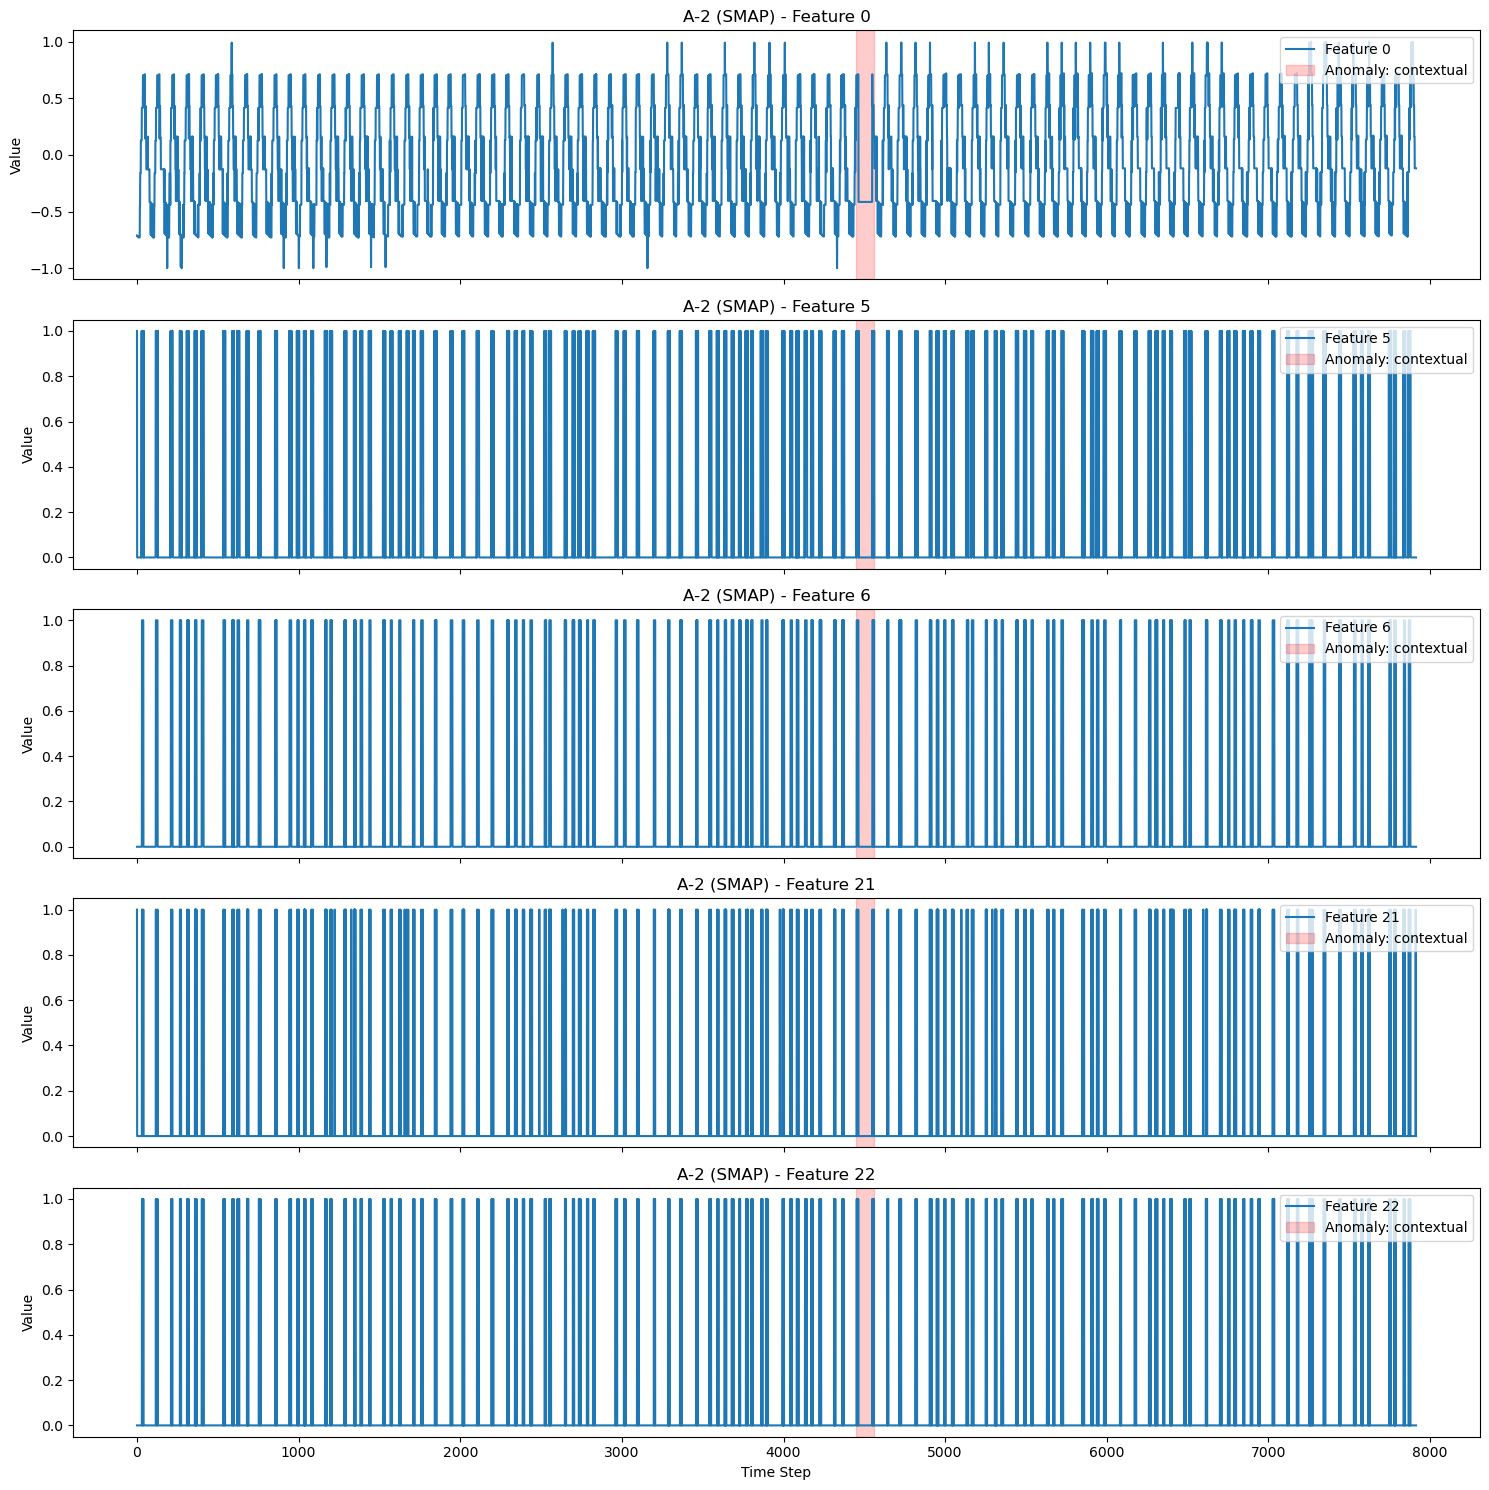

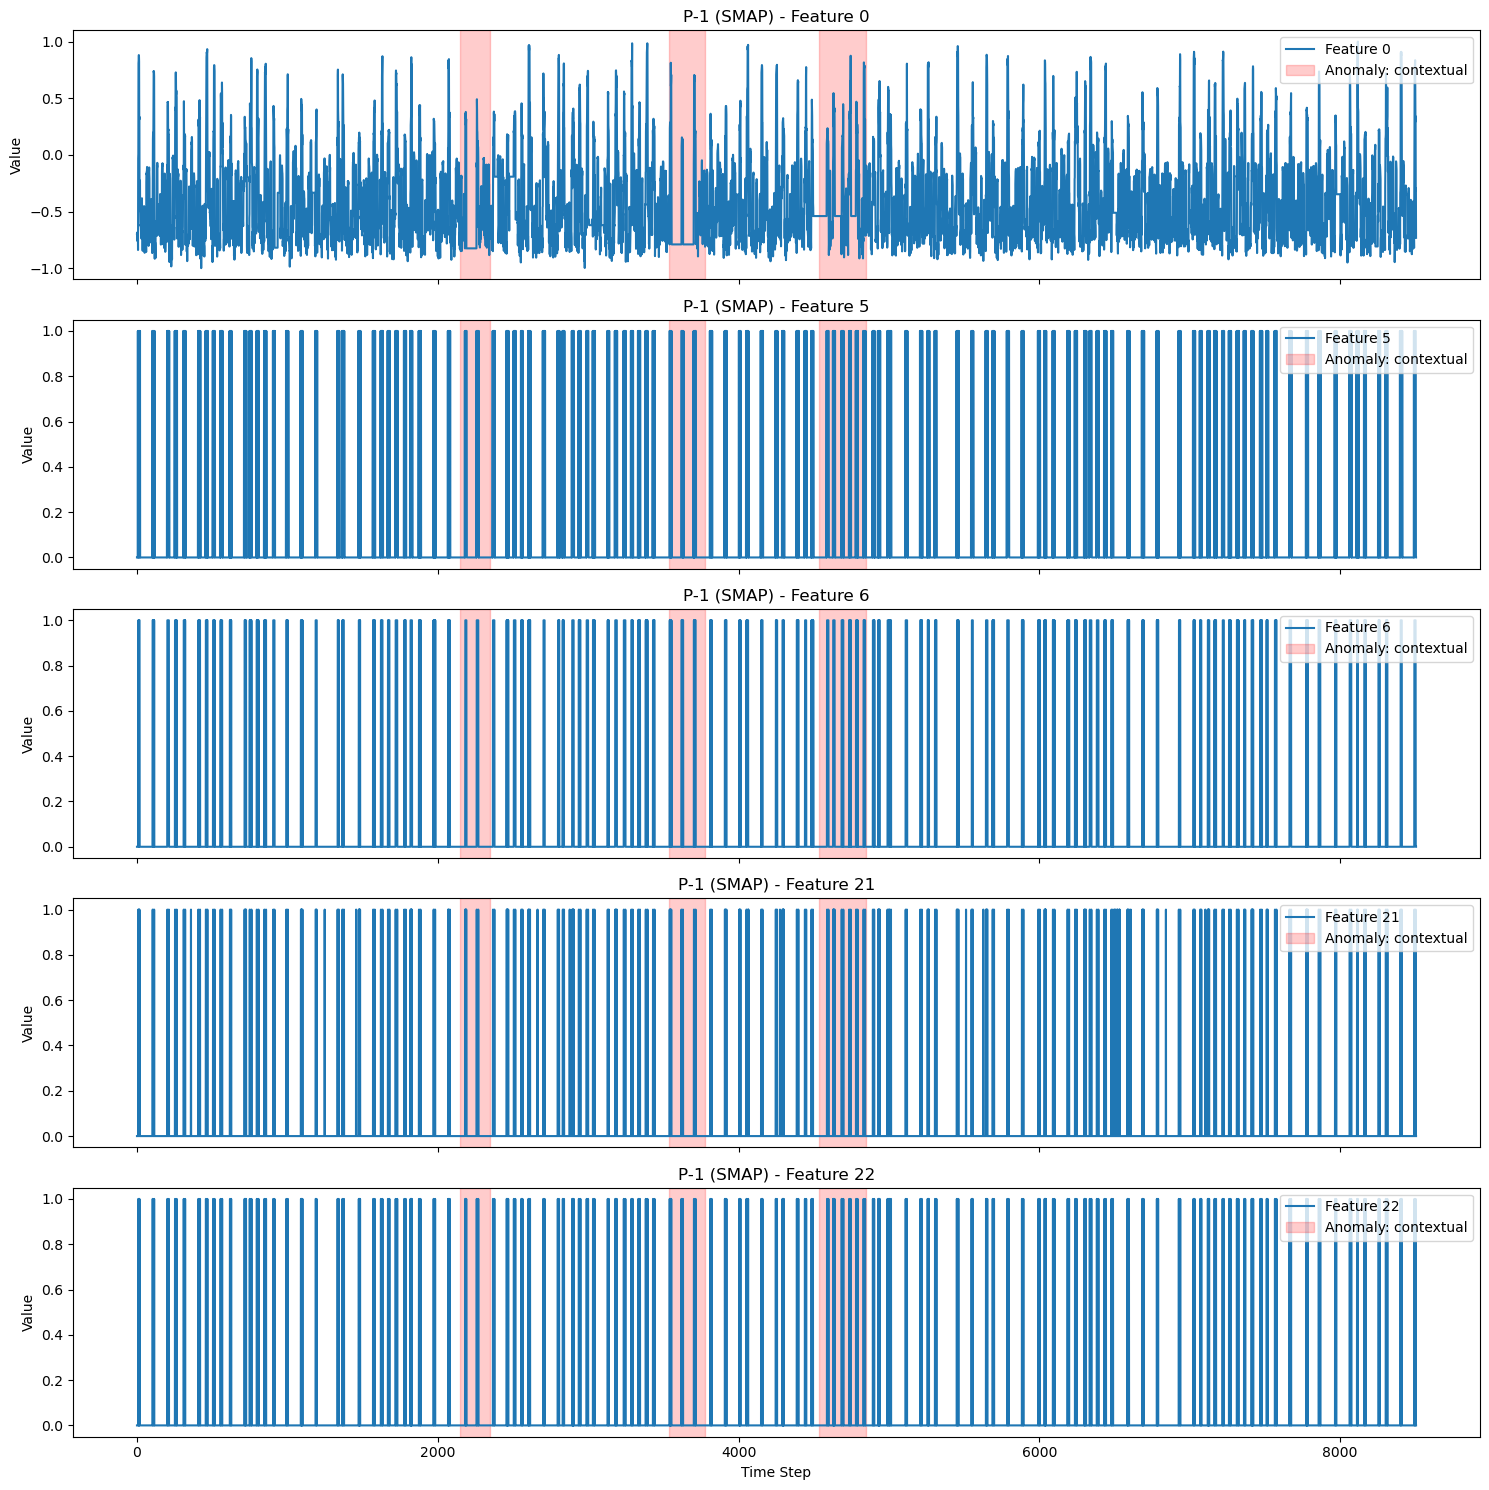

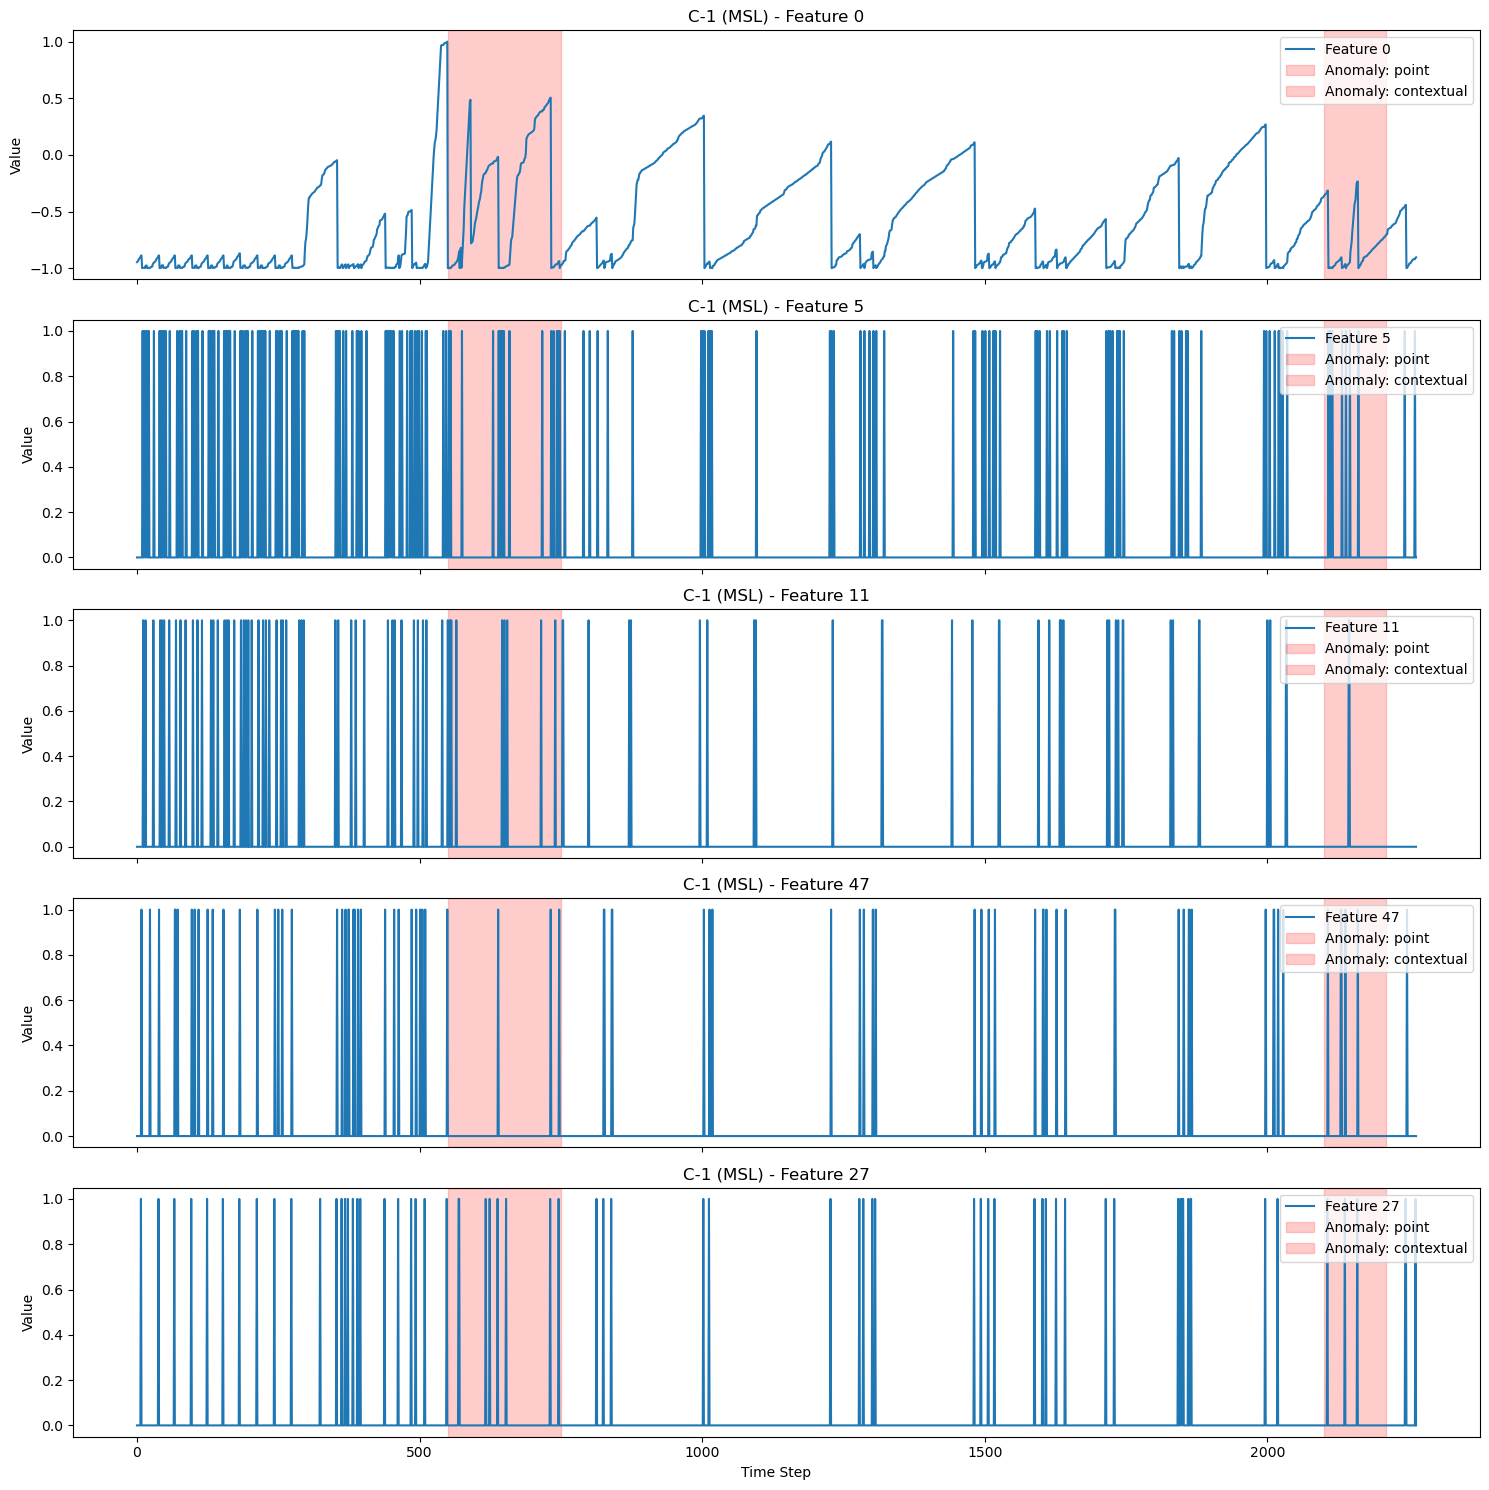

In [61]:
for channel_id in representative_channels:
    plot_top_variable_features(channel_id, labels_df, train_dir, test_dir, top_n=5)

In [58]:
representative_summary_rows = []

for channel_id in representative_channels:
    summary = summarize_channel(channel_id, labels_df, train_dir, test_dir)
    representative_summary_rows.append(summary)

representative_summary_df = pd.DataFrame(representative_summary_rows)

representative_summary_df[
    [
        "channel_id",
        "spacecraft",
        "train_shape",
        "test_shape",
        "num_features",
        "num_anomaly_intervals",
        "anomaly_classes",
        "anomalous_time_steps",
        "anomaly_percentage"
    ]
]

,channel_id,spacecraft,train_shape,test_shape,num_features,num_anomaly_intervals,anomaly_classes,anomalous_time_steps,anomaly_percentage
0,A-2,SMAP,"(2648, 25)","(7914, 25)",25,1,[contextual],111,1.40
1,P-1,SMAP,"(2872, 25)","(8505, 25)",25,3,"[contextual, contextual, contextual]",751,8.83
2,C-1,MSL,"(2158, 55)","(2264, 55)",55,2,"[point, contextual]",312,13.78


### Step 7 Observations

The quick EDA on representative channels confirms that anomaly behavior varies across the dataset.

`A-2` represents a SMAP contextual anomaly. The anomaly is not visually obvious as a single extreme value, suggesting that temporal context may be important.

`P-1` represents a SMAP channel with multiple contextual anomaly intervals. Its signal is noisy, and the anomaly regions are difficult to identify visually, making it a more challenging case.

`C-1` represents an MSL channel. It has a different feature dimension from SMAP channels and shows a different signal pattern, including ramp-like behavior in Feature `0`. It also contains both point and contextual anomaly intervals.

These observations confirm that the dataset includes both simple and complex anomaly cases. They also support the decision to start modeling with a consistent subset, such as SMAP channels, before extending the pipeline to MSL.

In [62]:
def plot_anomaly_zooms(channel_id, labels_df, train_dir, test_dir, feature_idx=0, padding=200):
    metadata = get_channel_metadata(labels_df, channel_id)
    _, test_data = load_channel_data(channel_id, train_dir, test_dir)
    
    anomaly_sequences = metadata["anomaly_sequences_parsed"]
    anomaly_classes = metadata["class_parsed"]
    spacecraft = metadata["spacecraft"]
    
    if test_data.ndim == 1:
        test_data_2d = test_data.reshape(-1, 1)
    else:
        test_data_2d = test_data
    
    feature_values = test_data_2d[:, feature_idx]
    
    for i, (start, end) in enumerate(anomaly_sequences):
        anomaly_class = anomaly_classes[i] if i < len(anomaly_classes) else "anomaly"
        
        zoom_start = max(0, start - padding)
        zoom_end = min(len(feature_values), end + padding)
        
        plt.figure(figsize=(15, 4))
        plt.plot(
            range(zoom_start, zoom_end),
            feature_values[zoom_start:zoom_end],
            label=f"Feature {feature_idx}"
        )
        
        plt.axvspan(start, end, color="red", alpha=0.2, label=f"Anomaly: {anomaly_class}")
        
        plt.title(
            f"Zoom Around Anomaly {i + 1} - {channel_id} ({spacecraft}) - Feature {feature_idx}"
        )
        plt.xlabel("Time Step")
        plt.ylabel("Value")
        plt.legend()
        plt.show()

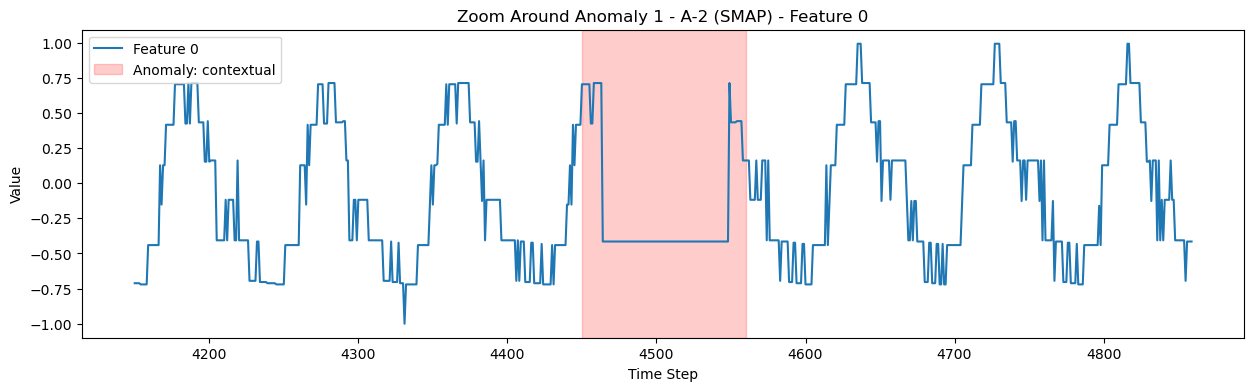

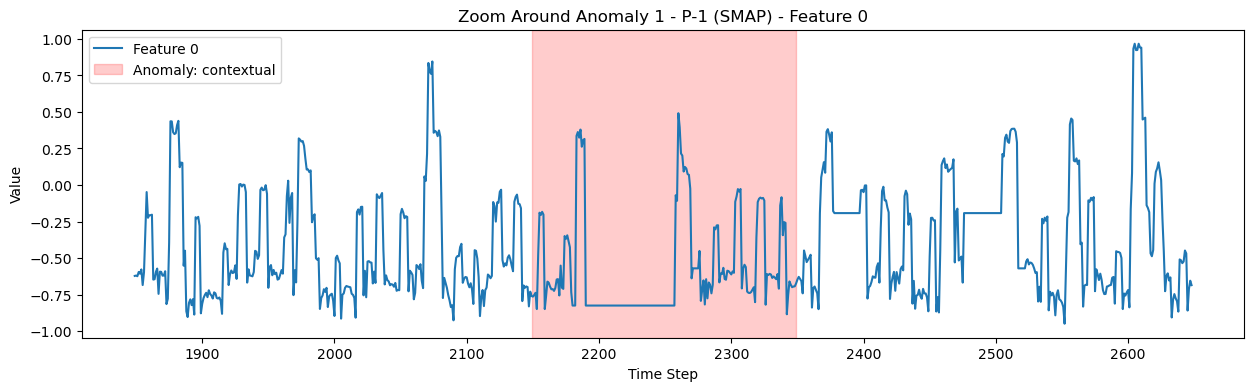

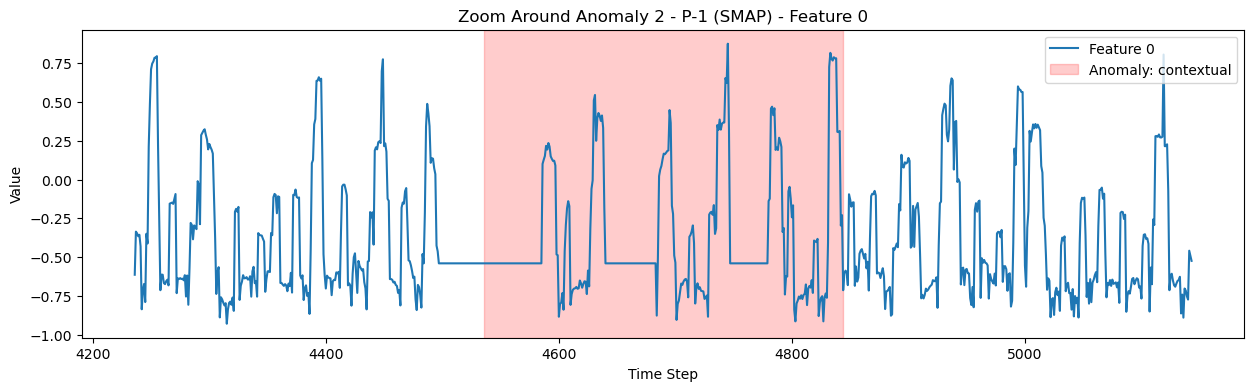

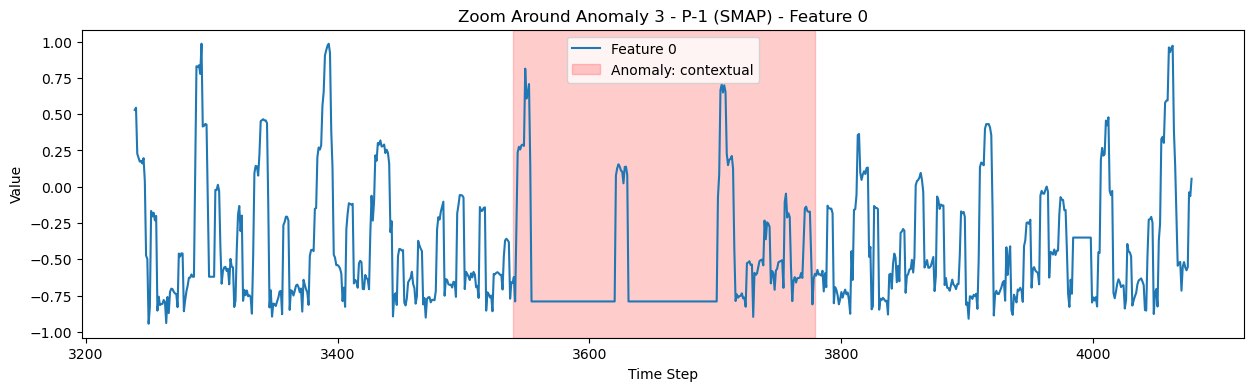

In [63]:
plot_anomaly_zooms("A-2", labels_df, train_dir, test_dir, feature_idx=0, padding=300)
plot_anomaly_zooms("P-1", labels_df, train_dir, test_dir, feature_idx=0, padding=300)

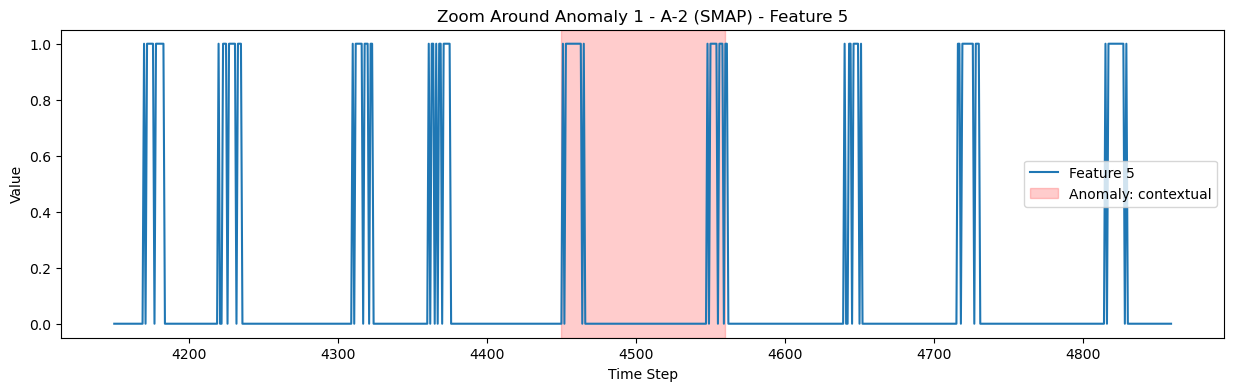

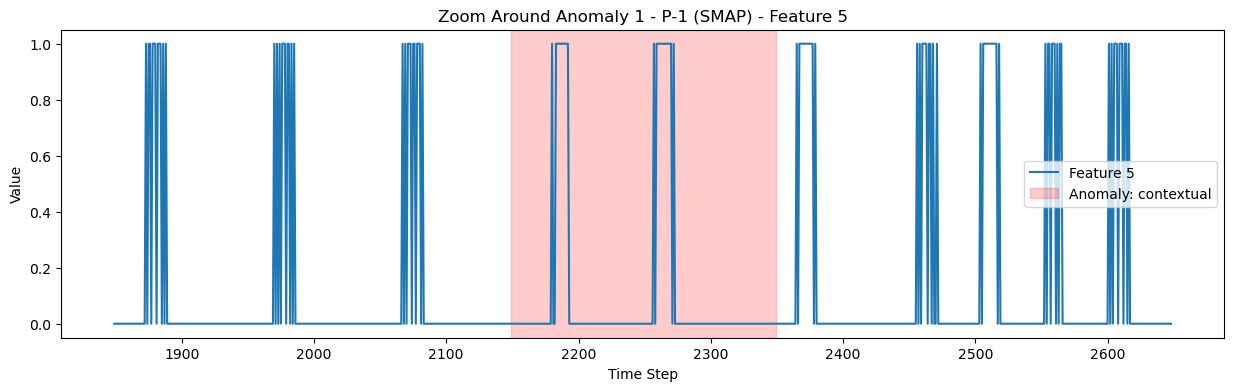

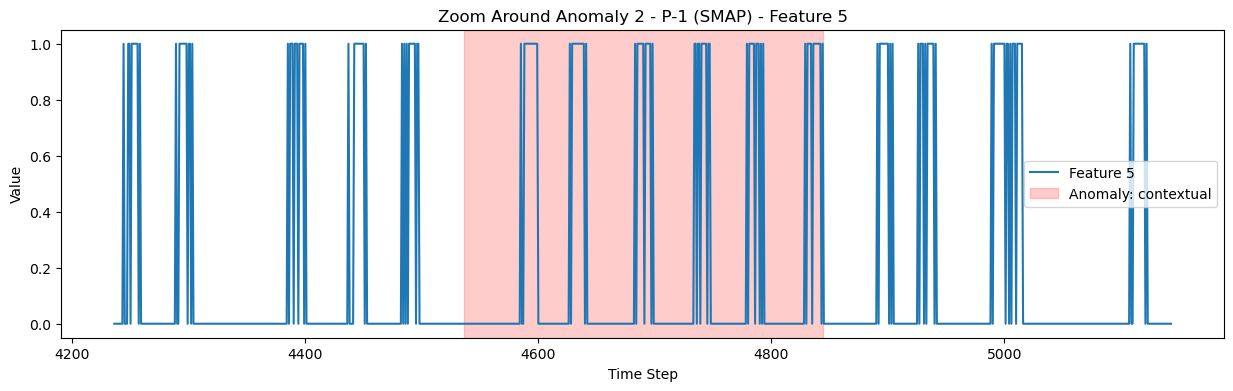

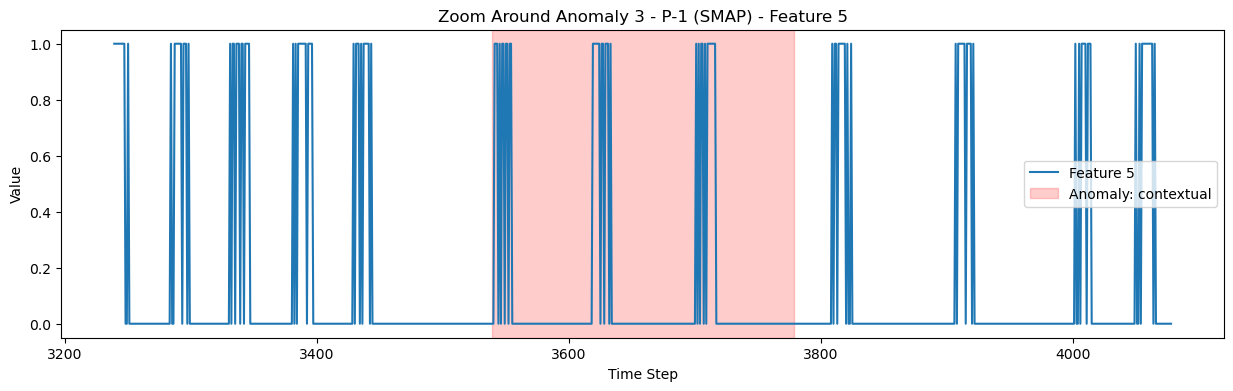

In [64]:
plot_anomaly_zooms("A-2", labels_df, train_dir, test_dir, feature_idx=5, padding=300)
plot_anomaly_zooms("P-1", labels_df, train_dir, test_dir, feature_idx=5, padding=300)

At this stage, not all anomalies are visually obvious from raw feature plots. Channel `A-1` shows a clear point-like abnormal change, but contextual anomaly examples such as `A-2` and `P-1` are harder to interpret visually.

This is expected because contextual anomalies may depend on temporal behavior, feature relationships, or subtle changes in signal patterns rather than a single extreme value.

Therefore, the current EDA is sufficient to understand the dataset structure and label alignment, but deeper anomaly interpretation will be revisited later using rolling statistics, baseline model scores, and error analysis.